In [8]:
#Импорт модулей
!pip install -q kagglehub
import kagglehub
from google.colab import files
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import shutil
import re
from sklearn.metrics import top_k_accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay


#Для Grad-CAM
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
#from IPython.display import Image, display
import matplotlib as mpl


In [9]:
#Загрузка датасета
files.upload() #Загрузить kaggle.json с локальной машины или с гитхаба в репозитории
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)
path = kagglehub.dataset_download("tanlikesmath/the-oxfordiiit-pet-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))
print(os.listdir(os.path.join(path, 'images')))
#path = "/kaggle/input/the-oxfordiiit-pet-dataset/images"

Saving kaggle.json to kaggle.json
Path to dataset files: /kaggle/input/the-oxfordiiit-pet-dataset
['images']
['american_pit_bull_terrier_16.jpg', 'leonberger_200.jpg', 'english_cocker_spaniel_35.jpg', 'Siamese_67.jpg', 'boxer_77.jpg', 'saint_bernard_146.jpg', 'american_bulldog_37.jpg', 'Sphynx_239.jpg', 'Egyptian_Mau_164.jpg', 'Birman_116.jpg', 'english_setter_178.jpg', 'Siamese_110.jpg', 'newfoundland_39.jpg', 'pug_84.jpg', 'yorkshire_terrier_47.jpg', 'Abyssinian_217.jpg', 'havanese_41.jpg', 'miniature_pinscher_50.jpg', 'chihuahua_170.jpg', 'american_pit_bull_terrier_95.jpg', 'basset_hound_141.jpg', 'saint_bernard_191.jpg', 'miniature_pinscher_152.jpg', 'scottish_terrier_150.jpg', 'basset_hound_149.jpg', 'newfoundland_100.jpg', 'saint_bernard_12.jpg', 'leonberger_50.jpg', 'boxer_112.jpg', 'scottish_terrier_161.jpg', 'Abyssinian_62.jpg', 'havanese_165.jpg', 'miniature_pinscher_37.jpg', 'scottish_terrier_84.jpg', 'english_cocker_spaniel_54.jpg', 'basset_hound_113.jpg', 'Bombay_217.jpg',

In [10]:
#Функция отображения изображений
def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

In [12]:
# Загрузка предобученных моделей с ImageNet
vgg16 = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
vgg19 = tf.keras.applications.VGG19(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
resnet = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

In [13]:
def create_model(base_model):
    base_model.trainable = False
    model = tf.keras.Sequential([base_model, tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'), tf.keras.layers.GlobalAveragePooling2D(), tf.keras.layers.Dense(64, activation='relu'), tf.keras.layers.Dense(38, activation='softmax')])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

vgg16_model = create_model(vgg16)
vgg19_model = create_model(vgg19)
resnet_model = create_model(resnet)

In [14]:
path = "/kaggle/input/the-oxfordiiit-pet-dataset/images"

breeds = ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau',
          'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx',
          'american_bulldog', 'american_pit_bull_terrier', 'beagle', 'basset_hound', 'boxer',
          'chihuahua', 'dalmatian', 'english_cocker_spaniel', 'english_setter',
          'german_shorthaired_pointer', 'great_pyrenees', 'havanese', 'keeshond',
          'labrador_retriever', 'leonberger', 'miniature_pinscher', 'pomeranian', 'pug',
          'rottweiler', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu',
          'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']

breed_to_label = {}
for idx, breed in enumerate(breeds):
    lower_breed = breed.lower()
    breed_to_label[lower_breed] = idx

def load_data(path, img_size=(64, 64)):
    images = []
    labels = []

    image_files = os.listdir(path)

    for filename in image_files:
        img_path = os.path.join(path, filename)
        breed_name = None

        for breed in breeds:
            if breed.lower() in filename.lower():
                breed_name = breed.lower()
                break

        if breed_name:
            try:
                img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
                img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                images.append(img_array)
                labels.append(breed_to_label[breed_name])
            except Exception as e:
                print(f"Не удалось загрузить изображение: {img_path}. Ошибка: {e}")
                continue

    images = tf.convert_to_tensor(images)
    labels = tf.convert_to_tensor(labels)

    return images, labels

images, labels = load_data(path)
X_train, X_test, y_train, y_test = train_test_split(images.numpy(), labels.numpy(), test_size=0.2, random_state=42)
X_train = tf.convert_to_tensor(X_train)
X_test = tf.convert_to_tensor(X_test)
y_train = tf.convert_to_tensor(y_train)
y_test = tf.convert_to_tensor(y_test)
print(f"Обучающие данные: {X_train.shape}, Тестовые данные: {X_test.shape}")
print(X_train)
print(y_train)

Не удалось загрузить изображение: /kaggle/input/the-oxfordiiit-pet-dataset/images/Abyssinian_100.mat. Ошибка: cannot identify image file <_io.BytesIO object at 0x7b2d34309670>
Не удалось загрузить изображение: /kaggle/input/the-oxfordiiit-pet-dataset/images/Abyssinian_102.mat. Ошибка: cannot identify image file <_io.BytesIO object at 0x7b2d3e5e39c0>
Не удалось загрузить изображение: /kaggle/input/the-oxfordiiit-pet-dataset/images/Abyssinian_101.mat. Ошибка: cannot identify image file <_io.BytesIO object at 0x7b2d34309670>
Обучающие данные: (5432, 64, 64, 3), Тестовые данные: (1358, 64, 64, 3)
tf.Tensor(
[[[[0.15686275 0.13333334 0.18039216]
   [0.20392157 0.16862746 0.1882353 ]
   [0.01176471 0.00392157 0.00784314]
   ...
   [0.08235294 0.2784314  0.16470589]
   [0.01176471 0.05098039 0.01568628]
   [0.         0.0627451  0.        ]]

  [[0.14509805 0.19215687 0.18431373]
   [0.         0.00784314 0.01568628]
   [0.02745098 0.08627451 0.05882353]
   ...
   [0.         0.04705882 0.007

In [21]:
# !!!Обучение моделей
def train_model(model, X_train, y_train, X_test, y_test, epochs=60, batch_size=32):
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test))
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    return test_accuracy, model

vgg16_accuracy, vgg16_model = train_model(vgg16_model, X_train, y_train, X_test, y_test)
vgg19_accuracy, vgg19_model = train_model(vgg19_model, X_train, y_train, X_test, y_test)
resnet_accuracy, resnet_model = train_model(resnet_model, X_train, y_train, X_test, y_test)

print(f"VGG16 Accuracy: {vgg16_accuracy}")
print(f"VGG19 Accuracy: {vgg19_accuracy}")
print(f"ResNet Accuracy: {resnet_accuracy}")

Epoch 1/60
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.4857 - loss: 1.7363 - val_accuracy: 0.2548 - val_loss: 2.7775
Epoch 2/60
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5189 - loss: 1.6482 - val_accuracy: 0.2577 - val_loss: 2.8315
Epoch 3/60
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.5493 - loss: 1.5641 - val_accuracy: 0.2695 - val_loss: 2.7960
Epoch 4/60
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5708 - loss: 1.5070 - val_accuracy: 0.2688 - val_loss: 2.8451
Epoch 5/60
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6020 - loss: 1.3820 - val_accuracy: 0.2725 - val_loss: 2.8688
Epoch 6/60
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6212 - loss: 1.3199 - val_accuracy: 0.2688 - val_loss: 2.9860
Epoch 7/60
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.6362 - loss: 1.2671 - val_accuracy: 0.2747 - val_loss: 2.9954
Epoch 8/60
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.6609 - loss: 1.1553 - val_accu

In [22]:
#Выбор лучшей модели
if (vgg16_accuracy > vgg19_accuracy) and (vgg16_accuracy > resnet_accuracy):
  best_model = vgg16_model
  best_accuracy = vgg16_accuracy
  best_model_name = "VGG16_modified"
elif (vgg19_accuracy > vgg16_accuracy) and (vgg19_accuracy > resnet_accuracy):
  best_model = vgg19_model
  best_accuracy = vgg19_accuracy
  best_model_name = "VGG19_modified"
elif (resnet_accuracy > vgg16_accuracy) and (resnet_accuracy > vgg19_accuracy):
  best_model = resnet_model
  best_accuracy = resnet_accuracy
  best_model_name = "RESNET_modified"
else:
  print("Схожие точности на высокой точности, вероятно, что-то пошло не так. Настройте модель вручную.")

model = best_model

print(f"Лучшей моделью является: {best_model_name} с точностью {best_accuracy}")

Лучшей моделью является: VGG16_modified с точностью 0.24594992399215698


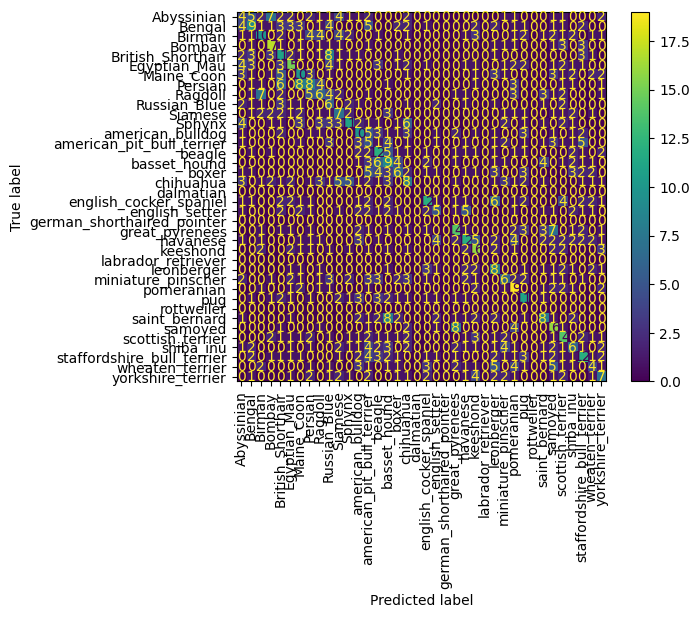

In [23]:
#Матрица ошибок многоклассовой клкассификации
pred_y = model.predict(X_test, verbose=0).argmax(axis=-1)
true_y = y_test.numpy() if isinstance(y_test, tf.Tensor) else y_test

ConfusionMatrixDisplay.from_predictions(true_y, pred_y, labels=range(38), display_labels=breeds)
plt.xticks(rotation=90)
plt.show()

In [25]:
#Top-3
top_k = 3
top_3_correct = 0
total = len(true_y)

for i in range(total):
    top_k_preds = np.argsort(pred_y[i])[-top_k:][::-1]
    if true_y[i] in top_k_preds:
        top_3_correct += 1

top_3_accuracy = top_3_correct / total
print(f"Top-3 Accuracy = {top_3_accuracy:.4f}")

#Top-5
top_k = 5
top_5_correct = 0

for i in range(total):
    top_k_preds = np.argsort(pred_y[i])[-top_k:][::-1]
    if true_y[i] in top_k_preds:
        top_5_correct += 1

top_5_accuracy = top_5_correct / total
print(f"Top-5 Accuracy = {top_5_accuracy:.4f}")

Top-3 Accuracy = 0.0309
Top-5 Accuracy = 0.0309


In [30]:
#Проверка, сколько кошек остались кошками, а сколько собак собаками и построение матрицы ошибок при многоклассовом классификаторе
pred_y = []
true_y = []

def reclass(x):
    return [0 if 0 <= i <= 11 else 1 for i in x]

for x, y in zip(X_test, y_test):
    pred_y.append(model.predict(x[None], verbose=0).argmax(axis=-1)[0])
    true_y.append(y.numpy())

pred_y = reclass(pred_y)
true_y = reclass(true_y)

print(f"Accuracy = {accuracy_score(true_y, pred_y)}")

ConfusionMatrixDisplay.from_predictions(true_y, pred_y, display_labels=['cats', 'dogs'])
plt.xticks(rotation=90)
plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

--2025-04-20 09:45:22--  https://kot-pes.com/wp-content/uploads/2019/02/post_5c606e629f934.jpg
Resolving kot-pes.com (kot-pes.com)... 104.21.80.1, 104.21.96.1, 104.21.112.1, ...
Connecting to kot-pes.com (kot-pes.com)|104.21.80.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 161127 (157K) [image/jpeg]
Saving to: ‘post_5c606e629f934.jpg.4’

post_5c606e629f934. 100%[===================>] 157.35K  --.-KB/s    in 0.01s   

2025-04-20 09:45:22 (13.3 MB/s) - ‘post_5c606e629f934.jpg.4’ saved [161127/161127]



AttributeError: 'InputLayer' object has no attribute 'layers'

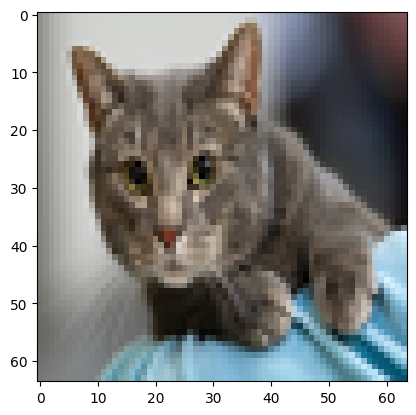

In [29]:
!wget https://kot-pes.com/wp-content/uploads/2019/02/post_5c606e629f934.jpg
img = np.array(Image.open('post_5c606e629f934.jpg').resize((64,64),Image.LANCZOS))
plt.imshow(img)
im = tf.keras.applications.vgg16.preprocess_input(np.expand_dims(img,0))

base_model = model.layers[0]

#for i, layer in enumerate(model.layers[0].layers):
#    print(i, layer.name)

for i, layer in enumerate(base_model.layers):
    print(i, layer.name)

model = base_model

grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer('block5_conv3').output, model.output]
    )
last_conv_layer_output, preds = grad_model(im)
last_conv_layer_output.shape, preds.shape
with tf.GradientTape() as tape:
  last_conv_layer_output, preds = grad_model(im)
  pred_index = tf.argmax(preds[0])
  #class_channel = preds[:, pred_index]
  class_channel = tf.gather(preds[0], pred_index)
  grads = tape.gradient(class_channel, last_conv_layer_output)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap.shape
plt.imshow(heatmap,cmap='jet')
plt.imshow(img)
import matplotlib as mpl

heatmap = np.uint8(255 * heatmap)

# Use jet colormap to colorize heatmap
jet = mpl.colormaps["jet"]

# Use RGB values of the colormap
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

# Create an image with RGB colorized heatmap
jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

alpha = 0.5

# Superimpose the heatmap on original image
superimposed_img = jet_heatmap * alpha + img
superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
superimposed_img